# EV Intelligence System

## Objective

Develop a machine learning system that analyzes EV telemetry data to:

- Predict driving behavior (Eco, Normal, Aggressive)
- Estimate energy consumption
- Generate driving recommendations
- Support efficient EV operation

## Workflow

1. Data preprocessing
2. Feature engineering
3. Exploratory Data Analysis
4. Model development
5. Explainability
6. Model export

In [1]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,r2_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
import joblib

In [2]:
# Loading dataset
df =pd.read_excel(r"C:\Users\Admin\Desktop\Shrawani\Projects\EV\EV intelligence system\data\EV_data.xlsx")

# Dataset Overview

The dataset contains telemetry collected from an Electric Vehicle (EV) during driving sessions.

Each record represents the operational state of the vehicle at a specific timestamp and includes measurements from the Battery Management System (BMS), Motor Control Unit (MCU), vehicle speed, torque, temperatures, and battery state of charge.

The objective is to analyze this telemetry to understand driving behavior and energy consumption patterns.

In [3]:
# first 5 rows from dataset
df.head()

,Time,Speed,Crank,Ignition,A_Batt_Current,A_Batt_Voltage,B_Batt_Current,B_Batt_Voltage,A_Batt_soc,B_Batt_soc,...,MCU_temp,Motor_temp,Accel_pedal,MCU_torque,MCU_Speed,MCU_Current_DC,MCU_Voltage_DC,MCU_AC_Voltage,MCU_AC_Current,Odometer
0,115.8,-3,1,1,-3.0,688.6,-3.5,688.6,100.0,100.0,...,35,31,4,-150.5,-94,3.5,687.2,21.5,56.7,10010.7
1,115.9,-3,1,1,-3.0,688.4,-3.5,688.4,100.0,100.0,...,35,31,4,-139.8,-94,3.1,688.0,20.7,53.9,10010.7
2,116.2,-3,1,1,-2.5,688.6,-3.5,688.6,100.0,100.0,...,35,31,4,-114.8,-97,2.5,688.7,20.1,46.2,10010.7
3,116.4,-3,1,1,-2.5,688.6,-3.0,688.6,100.0,100.0,...,35,31,3,-100.6,-99,2.3,687.3,20.3,41.4,10010.7
4,116.5,-3,1,1,-3.0,688.6,-3.0,688.6,100.0,100.0,...,35,31,0,-64.5,-93,1.8,687.9,17.8,39.2,10010.7


In [4]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 167908
Number of Columns : 27


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167908 entries, 0 to 167907
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Time                     167908 non-null  float64
 1   Speed                    167908 non-null  int64  
 2   Crank                    167908 non-null  int64  
 3   Ignition                 167908 non-null  int64  
 4   A_Batt_Current           167908 non-null  float64
 5   A_Batt_Voltage           167908 non-null  float64
 6   B_Batt_Current           167908 non-null  float64
 7   B_Batt_Voltage           167908 non-null  float64
 8   A_Batt_soc               167908 non-null  float64
 9   B_Batt_soc               167908 non-null  float64
 10  B_Batt_Charge_energy     167908 non-null  float64
 11  B_Batt_Discharge_energy  167908 non-null  float64
 12  B_Batt_Regen_energy      167908 non-null  float64
 13  A_Batt_Charge_energy     167908 non-null  float64
 14  A_Ba

## Missing values

In [6]:
df.isnull().sum()

Time                       0
Speed                      0
Crank                      0
Ignition                   0
A_Batt_Current             0
A_Batt_Voltage             0
B_Batt_Current             0
B_Batt_Voltage             0
A_Batt_soc                 0
B_Batt_soc                 0
B_Batt_Charge_energy       0
B_Batt_Discharge_energy    0
B_Batt_Regen_energy        0
A_Batt_Charge_energy       0
A_Batt_Discharge energy    0
A_Batt_Regen_energy        0
Torque                     0
MCU_temp                   0
Motor_temp                 0
Accel_pedal                0
MCU_torque                 0
MCU_Speed                  0
MCU_Current_DC             0
MCU_Voltage_DC             0
MCU_AC_Voltage             0
MCU_AC_Current             0
Odometer                   0
dtype: int64

#### Observation

- This dataset does not contain any missing values

## Duplicate Records

In [7]:
df.duplicated().sum()

np.int64(0)

#### Observation

- This dataset does not contain any missing values

## Statistical Summary

In [8]:
df.describe()

,Time,Speed,Crank,Ignition,A_Batt_Current,A_Batt_Voltage,B_Batt_Current,B_Batt_Voltage,A_Batt_soc,B_Batt_soc,...,MCU_temp,Motor_temp,Accel_pedal,MCU_torque,MCU_Speed,MCU_Current_DC,MCU_Voltage_DC,MCU_AC_Voltage,MCU_AC_Current,Odometer
count,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,...,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000
mean,8395.350000,37.528605,0.994985,0.999071,-18.077879,677.564992,-18.590037,677.564992,68.806759,68.392492,...,34.484009,38.733056,53.917133,147.176479,1212.308407,37.067276,673.928479,312.494297,42.492583,10074.017006
std,4847.100884,17.648891,0.070637,0.030467,14.813569,5.518851,16.052850,5.518851,17.934187,18.409098,...,6.302457,7.574951,28.784129,184.179764,568.836951,32.949798,48.401498,143.444061,31.169425,558.299602
min,0.000000,-3.000000,0.000000,0.000000,-75.000000,0.000000,-84.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-891.900000,-123.000000,-108.900000,0.000000,0.000000,0.000000,0.000000
25%,4197.675000,38.000000,1.000000,1.000000,-25.500000,672.500000,-26.500000,672.500000,53.200000,52.300000,...,28.000000,32.000000,41.000000,68.700000,1232.000000,15.100000,672.100000,331.300000,25.100000,10055.500000
50%,8395.350000,46.000000,1.000000,1.000000,-19.000000,679.100000,-19.500000,679.100000,65.700000,65.900000,...,38.000000,39.000000,64.000000,145.800000,1475.000000,38.000000,678.800000,377.200000,39.200000,10110.200000
75%,12593.025000,48.000000,1.000000,1.000000,-9.000000,681.500000,-8.500000,681.500000,85.100000,85.000000,...,40.000000,46.000000,73.000000,207.600000,1557.000000,52.700000,681.500000,393.200000,54.700000,10151.700000
max,16790.700000,56.000000,1.000000,1.000000,62.000000,692.000000,71.500000,692.000000,100.000000,100.000000,...,47.000000,55.000000,100.000000,1579.700000,1812.000000,187.000000,693.100000,474.200000,272.500000,10205.700000


### Vehicle Speed
- The average vehicle speed is 37.53 km/h, with most observations between 38 km/h and 48 km/h.
- The maximum recorded speed is 56 km/h, indicating that the dataset primarily represents urban or controlled driving conditions.
- A minimum speed of -3 km/h may represent reverse motion or a sensor artifact and should be investigated further.
### Battery Current & Voltage
- Both battery packs exhibit an average current of approximately -18 A, indicating battery discharge during normal vehicle operation.
- Positive current values likely correspond to regenerative braking or charging events.
- Battery voltage remains relatively stable around 678 V, suggesting consistent battery performance.
### Battery State of Charge (SOC)
- The average SOC is approximately 68% for both battery packs.
- SOC values span the full operational range (0–100%), making it a valuable feature for analyzing energy consumption and driving efficiency.
### Motor & MCU Temperature
- The average Motor Temperature is 38.7°C, while the MCU Temperature averages 34.5°C.
- Most values fall within a normal operating range, indicating stable thermal conditions during vehicle operation.
### Motor Torque
- Motor torque shows substantial variability, ranging from -891.9 Nm to 1579.7 Nm.
- Negative torque values likely correspond to regenerative braking, where the motor recovers energy.
### Electrical Current
- DC and AC current values exhibit considerable variation, reflecting different power demands under varying driving conditions.
- These features are expected to be important predictors of driving behavior.
### Odometer
- The odometer increases from 0 km to approximately 10,206 km.
- As a cumulative measure, it may not directly contribute to driving behavior prediction and should be evaluated carefully before model training.

## Key Observations
- The dataset captures a wide range of EV operating conditions.
- Most telemetry values fall within realistic operating limits.
- A few zero or negative values require domain-specific interpretation rather than immediate removal.
- Features such as Speed, Motor Temperature, MCU Temperature, Battery SOC, Torque, and Electrical Current are expected to play a significant role in
- predicting driving behavior.

In [9]:
#Let's remove unnessesary rows by considering valid conditions

In [10]:
df=df[(df["Ignition"]==1) & (df["Crank"]==1) & (df["Speed"]>0)].reset_index(drop=True)

In [11]:
df.shape

(145058, 27)

# Feature Engineering

Feature engineering is the process of creating new variables from the existing telemetry data to better capture vehicle behavior and improve model performance.

Instead of relying only on raw sensor measurements, domain-specific features were engineered to represent electrical power consumption, vehicle dynamics, thermal behavior, and battery characteristics. These engineered features provide more meaningful information for both energy consumption prediction and driving behavior classification.

## 1. Time-based Features

The telemetry data contains timestamp information for each observation. To calculate rate-based quantities such as acceleration and jerk, the time difference between consecutive observations is computed.

The `dt` feature represents the elapsed time between two consecutive telemetry records and serves as the foundation for subsequent driving dynamics calculations.

In [12]:
df["dt"]=df["Time"].diff().fillna(0.1)

In [13]:
df["dt"].describe()

count    145058.000000
mean          0.112433
std         302.803822
min      -15588.700000
25%           0.100000
50%           0.100000
75%           0.100000
max        9516.300000
Name: dt, dtype: float64

In [14]:
df["dt"].value_counts().head(10)

dt
0.1    76983
0.1    21096
0.1    15136
0.1    14991
0.1     4014
0.1     3928
0.1     1564
0.2      562
0.2      459
0.2      283
Name: count, dtype: int64

In [15]:
df["Time"].describe()

count    145058.000000
mean       8499.224659
std        4904.571441
min         137.100000
25%        4262.625000
50%        8023.550000
75%       12860.375000
max       16790.700000
Name: Time, dtype: float64

In [16]:
df["Time"].head(20)

0     137.1
1     137.2
2     137.3
3     137.4
4     137.5
5     137.6
6     167.8
7     167.9
8     168.0
9     472.2
10    472.3
11    472.4
12    472.5
13    472.6
14    472.7
15    472.8
16    483.6
17    483.7
18    483.8
19    483.9
Name: Time, dtype: float64

In [17]:
df["Time"].tail(20)

145038     6926.3
145039     6926.4
145040     6926.5
145041     6926.6
145042     6926.7
145043     6926.8
145044     6926.9
145045     6927.0
145046     6927.1
145047     6927.2
145048     6927.3
145049     6927.4
145050     6927.5
145051     6927.6
145052     6927.7
145053     6927.8
145054     6927.9
145055    16444.2
145056    16446.2
145057    16446.3
Name: Time, dtype: float64

In [18]:
negative_jumps = (df["Time"].diff() < 0).sum()

print(f"Number of timestamp resets detected: {negative_jumps}")

Number of timestamp resets detected: 55


## Trip Segmentation and Timestamp Correction

The telemetry dataset contains data collected from multiple driving sessions. During exploratory analysis, two timestamp-related issues were identified:

1. **Timestamp Reset:** The `Time` column resets at the beginning of a new driving session, resulting in large negative time differences (`dt`).
2. **Long Recording Gaps:** Within some driving sessions, the timestamp increases by several minutes or hours due to temporary data logging interruptions or vehicle idle periods.

These discontinuities can produce unrealistic values for time-dependent features such as acceleration, jerk, rolling distance, and vehicle efficiency.

To address these issues:

- A new driving trip is detected whenever the timestamp decreases.
- Within each trip, additional driving segments are created whenever the elapsed time between consecutive observations exceeds a predefined threshold (5 seconds).
- The time interval (`dt`) is then recalculated independently for each continuous driving segment.

This preprocessing ensures that all subsequent temporal features are computed using continuous vehicle movement, improving the reliability of both the driving behavior classification model and the vehicle efficiency prediction model.

In [19]:
# ---------------------------------------------
# Step 1: Identify new trips (Time reset)
# ---------------------------------------------

df["Trip_ID"] = (df["Time"].diff() < 0).cumsum()


# ---------------------------------------------
# Step 2: Calculate temporary dt within trips
# ---------------------------------------------

df["temp_dt"] = (
    df.groupby("Trip_ID")["Time"]
      .diff()
      .fillna(0.1)
)


# ---------------------------------------------
# Step 3: Identify telemetry gaps >= 5 seconds
# ---------------------------------------------

gap_threshold = 5  # seconds

df["Segment_Break"] = (
    df["temp_dt"] >= gap_threshold
).astype(int)


# ---------------------------------------------
# Step 4: Create segment number within each trip
# ---------------------------------------------

df["Segment_Number"] = (
    df.groupby("Trip_ID")["Segment_Break"]
      .cumsum()
)


# ---------------------------------------------
# Step 5: Create unique continuous driving segment ID
# ---------------------------------------------

df["Driving_Segment_ID"] = (
    df["Trip_ID"].astype(str)
    + "_"
    + df["Segment_Number"].astype(str)
)


# ---------------------------------------------
# Step 6: Recalculate dt within each segment
# ---------------------------------------------

df["dt"] = (
    df.groupby("Driving_Segment_ID")["Time"]
      .diff()
      .fillna(0.1)
)


# ---------------------------------------------
# Step 7: Remove temporary columns
# ---------------------------------------------

df.drop(
    columns=["temp_dt", "Segment_Break", "Segment_Number"],
    inplace=True
)

In [20]:
print("="*60)

print("Total Trips:")
print(df["Trip_ID"].nunique())

print("\nContinuous Driving Segments:")
print(df["Driving_Segment_ID"].nunique())

print("\nNegative dt values:")
print((df["dt"] < 0).sum())

print("\nLarge dt (>5 sec):")
print((df["dt"] > 5).sum())

print("\nSummary of corrected dt:")
print(df["dt"].describe())

print("="*60)

print("\nTrip Statistics")
print(df.groupby("Trip_ID").size().describe())

print("\nDriving Segment Statistics")
print(df.groupby("Driving_Segment_ID").size().describe())

Total Trips:
56

Continuous Driving Segments:
3389

Negative dt values:
0

Large dt (>5 sec):
0

Summary of corrected dt:
count    145058.000000
mean          0.114074
std           0.175508
min           0.100000
25%           0.100000
50%           0.100000
75%           0.100000
max           4.900000
Name: dt, dtype: float64

Trip Statistics
count       56.000000
mean      2590.321429
std       4637.914285
min         46.000000
25%        393.750000
50%        557.000000
75%       1729.750000
max      17183.000000
dtype: float64

Driving Segment Statistics
count    3389.000000
mean       42.802597
std        74.810084
min         1.000000
25%         6.000000
50%        15.000000
75%        47.000000
max      1078.000000
dtype: float64


### Validation of Trip Segmentation and Timestamp Correction

The preprocessing pipeline successfully corrected timestamp discontinuities present in the telemetry dataset.

**Validation Results**

- Identified **56 independent driving trips** based on timestamp resets.
- Further divided these trips into **3378 continuous driving segments** by detecting telemetry gaps greater than 5 seconds.
- Eliminated all negative time intervals (`dt`).
- Long temporal gaps were identified and used to create new continuous driving segments, ensuring that temporal features are computed only within     uninterrupted driving periods.
- The corrected `dt` has a median sampling interval of **0.1 seconds**, which matches the original telemetry sampling rate.

These preprocessing steps ensure that all time-dependent features, including acceleration, jerk, rolling statistics, and vehicle efficiency, are computed using continuous and physically meaningful driving data, thereby improving the reliability of both predictive models.

## 2. Electrical Power Features

Electrical power is one of the most important indicators of energy consumption in an electric vehicle.

Power is calculated using the relationship:

Power = Voltage × Current

Power is computed separately for Battery Pack A and Battery Pack B, and then combined to estimate the total electrical power delivered by the battery system.

Higher power demand generally corresponds to increased energy consumption and more aggressive driving behavior.

In [21]:
df['Power_A'] = df['A_Batt_Voltage'] * df['A_Batt_Current']
df['Power_B'] = df['B_Batt_Voltage'] * df['B_Batt_Current']
df['Total_Power'] = df['Power_A'] + df['Power_B']

## 3. Driving Dynamics Features

Driving behavior is influenced not only by vehicle speed but also by how quickly the speed changes over time.

To capture these dynamic characteristics, acceleration and jerk are computed.

- **Acceleration** measures the rate of change of speed and helps identify rapid acceleration or braking events.
- **Jerk** measures the rate of change of acceleration and reflects sudden changes in driver input.

These features help distinguish between smooth and aggressive driving styles.

In [22]:
speed_diff = (
    df.groupby("Driving_Segment_ID")["Speed"]
      .diff()
)

print(speed_diff.describe())

print("\nNon-zero speed changes:")
print((speed_diff != 0).sum())

print("\nFirst non-zero speed changes:")
print(
    df.loc[
        speed_diff != 0,
        ["Driving_Segment_ID", "Time", "Speed", "dt"]
    ].head(20)
)

count    141669.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Speed, dtype: float64

Non-zero speed changes:
3389

First non-zero speed changes:
    Driving_Segment_ID    Time  Speed   dt
0                  0_0   137.1      1  0.1
6                  0_1   167.8      1  0.1
9                  0_2   472.2      1  0.1
16                 0_3   483.6      1  0.1
56                 0_4   867.9      1  0.1
66                 0_5   884.2      1  0.1
80                 0_6   903.6      1  0.1
138                0_7  3140.0      1  0.1
142                0_8  3298.7      1  0.1
170                0_9  3322.0      1  0.1
206               0_10  7280.7      1  0.1
207               0_11  7415.3      1  0.1
215               0_12  8137.8      1  0.1
234               0_13  9056.4      1  0.1
237               0_14  9208.8      1  0.1
245               0_15  9292.3      1  0.1
249               0_16  9314.7      

In [23]:
print(df[[
    "Driving_Segment_ID",
    "Time",
    "Speed",
    "dt"
]].head(30))

   Driving_Segment_ID   Time  Speed   dt
0                 0_0  137.1      1  0.1
1                 0_0  137.2      1  0.1
2                 0_0  137.3      1  0.1
3                 0_0  137.4      1  0.1
4                 0_0  137.5      1  0.1
5                 0_0  137.6      1  0.1
6                 0_1  167.8      1  0.1
7                 0_1  167.9      1  0.1
8                 0_1  168.0      1  0.1
9                 0_2  472.2      1  0.1
10                0_2  472.3      1  0.1
11                0_2  472.4      1  0.1
12                0_2  472.5      1  0.1
13                0_2  472.6      1  0.1
14                0_2  472.7      1  0.1
15                0_2  472.8      1  0.1
16                0_3  483.6      1  0.1
17                0_3  483.7      1  0.1
18                0_3  483.8      1  0.1
19                0_3  483.9      1  0.1
20                0_3  484.0      1  0.1
21                0_3  484.1      1  0.1
22                0_3  484.2      1  0.1
23              

## 4. Torque-based Features

Torque represents the rotational force generated by the electric motor and is directly related to vehicle propulsion.

Two additional torque-based features are created:

- **Torque Load** estimates the mechanical workload by combining vehicle speed and motor torque.
- **Torque Ratio** normalizes torque with respect to speed, allowing comparison across different operating conditions.

These features provide valuable information about vehicle load and driving intensity.

In [25]:
df['Torque_Load'] = df['Torque'] * df['Speed']
df['Torque_Ratio'] = df['Torque'] / (df['Speed']+1)

## 5. Thermal Features

The thermal behavior of an electric vehicle provides important information about component operating conditions.

The temperature difference between the electric motor and the Motor Control Unit (MCU) is calculated to capture thermal imbalance during vehicle operation.

Large temperature differences may indicate increased electrical or mechanical loading.

In [26]:
df['Temp_diff'] = df['Motor_temp'] - df['MCU_temp']

## 6. Battery State of Charge (SOC) Features

Battery State of Charge (SOC) represents the remaining energy available in the battery pack.

Two additional SOC-based features are engineered:

- **Total SOC** represents the combined battery state of both battery packs.
- **SOC Drop** measures the change in battery charge between consecutive observations, providing an indication of battery discharge over time.

These features are expected to improve the prediction of vehicle energy consumption.

In [27]:
df["Total_SOC"]=df["A_Batt_soc"]+df["B_Batt_soc"]

In [28]:
df['SOC_drop'] = df['Total_SOC'].diff().fillna(0)

## 7. Power Magnitude

The battery current in the telemetry dataset follows the EV convention where negative current indicates battery discharge and positive current indicates charging or regenerative braking.

Since the objective is to quantify the electrical demand placed on the battery, only the magnitude of power consumption is required for target variable engineering.

Therefore, the absolute value of the total electrical power is calculated to represent the intensity of power demand irrespective of its direction.

In [29]:
df["Power_Magnitude"] = df["Total_Power"].abs()

## Summary of Engineered Features

| Category                | Engineered Features                            |
| ----------------------- | ---------------------------------------------- |
| **Time Features**       | dt                                             |
| **Power Features**      | Power_A, Power_B, Total_Power, Power_Magnitude |
| **Vehicle Dynamics**    | Acceleration, Jerk                             |
| **Mechanical Features** | Torque_Load, Torque_Ratio                      |
| **Thermal Features**    | Temp_diff                                      |
| **Battery Features**    | Total_SOC, SOC_drop                            |



# Quantile Analysis

To create rule-based driving behavior labels, the distributions of the selected telemetry features are analyzed using quartiles.

The selected features represent different aspects of vehicle operation:

- Accelerator Pedal → Driver intent
- Speed → Vehicle motion
- Torque Load → Mechanical workload
- Power Magnitude → Electrical energy demand
- MCU DC Current → Motor electrical load

Quartiles provide data-driven thresholds for identifying low, medium, and high operating conditions without relying on arbitrary values.

In [42]:
# =============================================
# Driving Style Scoring Setup
# =============================================

def score_feature(value, q1, q3):
    """
    Convert a feature value into a 0-2 score
    based on its Q1 and Q3 thresholds.
    """
    if value <= q1:
        return 0
    elif value >= q3:
        return 2
    else:
        return 1


# Calculate Q1 and Q3 thresholds
scoring_features = [
    "Accel_pedal",
    "Speed",
    "Torque_Load",
    "Power_Magnitude",
    "MCU_Current_DC"
]

thresholds = {}

for feature in scoring_features:
    thresholds[feature] = {
        "Q1": df[feature].quantile(0.25),
        "Q3": df[feature].quantile(0.75)
    }

print("Scoring function and thresholds created successfully.")
print(thresholds)

Scoring function and thresholds created successfully.
{'Accel_pedal': {'Q1': np.float64(56.0), 'Q3': np.float64(75.0)}, 'Speed': {'Q1': np.float64(44.0), 'Q3': np.float64(49.0)}, 'Torque_Load': {'Q1': np.float64(5004.8), 'Q3': np.float64(9845.75)}, 'Power_Magnitude': {'Q1': np.float64(21193.199999999997), 'Q3': np.float64(37996.25)}, 'MCU_Current_DC': {'Q1': np.float64(28.4), 'Q3': np.float64(56.0)}}


In [36]:
# Features selected for rule-based driving behavior labeling

target_features = [
    "Accel_pedal",
    "Speed",
    "Torque_Load",
    "Power_Magnitude",
    "MCU_Current_DC"
]



In [37]:
# Calculate quartiles

quantiles = df[target_features].quantile([0.25, 0.50, 0.75]).T


In [38]:
quantiles.columns = ["25th Percentile (Q1)",
                     "50th Percentile (Median)",
                     "75th Percentile (Q3)"]

quantiles.style.format("{:.2f}")

,25th Percentile (Q1),50th Percentile (Median),75th Percentile (Q3)
Accel_pedal,56.00,67.00,75.00
Speed,44.00,46.00,49.00
Torque_Load,5004.80,7324.80,9845.75
Power_Magnitude,21193.20,28822.90,37996.25
MCU_Current_DC,28.40,41.40,56.00


## Interpretation

The quartiles summarize the distribution of each telemetry feature and serve as the basis for defining driving intensity levels.

For each feature:

- Values less than or equal to the 25th percentile (Q1) represent **Low** operating conditions.
- Values between the 25th percentile (Q1) and the 75th percentile (Q3) represent **Medium** operating conditions.
- Values greater than the 75th percentile (Q3) represent **High** operating conditions.

Using percentile-based thresholds ensures that the rule-based driving behavior labels are derived from the characteristics of the dataset rather than arbitrary cutoff values.

# Rule-Based Feature Scoring

Each telemetry feature is converted into a numerical score based on its quartile distribution.

For every feature:

- **Low (≤ Q1)** → Score **0**
- **Medium (Q1 < value ≤ Q3)** → Score **1**
- **High (> Q3)** → Score **2**

Using a common scoring function ensures consistency across all features and makes the target engineering process transparent and reproducible.

In [39]:
thresholds = {
    feature: {
        "Q1": quantiles.loc[feature, "25th Percentile (Q1)"],
        "Q3": quantiles.loc[feature, "75th Percentile (Q3)"]
    }
    for feature in quantiles.index
}

thresholds

{'Accel_pedal': {'Q1': np.float64(56.0), 'Q3': np.float64(75.0)},
 'Speed': {'Q1': np.float64(44.0), 'Q3': np.float64(49.0)},
 'Torque_Load': {'Q1': np.float64(5004.8), 'Q3': np.float64(9845.75)},
 'Power_Magnitude': {'Q1': np.float64(21193.199999999997),
  'Q3': np.float64(37996.25)},
 'MCU_Current_DC': {'Q1': np.float64(28.4), 'Q3': np.float64(56.0)}}

In [43]:
df["Accel_score"] = df["Accel_pedal"].apply(
    lambda x: score_feature(
        x,
        thresholds["Accel_pedal"]["Q1"],
        thresholds["Accel_pedal"]["Q3"]
    )
)

df["Speed_score"] = df["Speed"].apply(
    lambda x: score_feature(
        x,
        thresholds["Speed"]["Q1"],
        thresholds["Speed"]["Q3"]
    )
)

df["Torque_score"] = df["Torque_Load"].apply(
    lambda x: score_feature(
        x,
        thresholds["Torque_Load"]["Q1"],
        thresholds["Torque_Load"]["Q3"]
    )
)

df["Power_score"] = df["Power_Magnitude"].apply(
    lambda x: score_feature(
        x,
        thresholds["Power_Magnitude"]["Q1"],
        thresholds["Power_Magnitude"]["Q3"]
    )
)

df["Current_score"] = df["MCU_Current_DC"].apply(
    lambda x: score_feature(
        x,
        thresholds["MCU_Current_DC"]["Q1"],
        thresholds["MCU_Current_DC"]["Q3"]
    )
)

In [44]:
score_columns = [
    "Accel_score",
    "Speed_score",
    "Torque_score",
    "Power_score",
    "Current_score"
]

df[score_columns].head()

,Accel_score,Speed_score,Torque_score,Power_score,Current_score
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0


# Driving Score Calculation

Each telemetry feature contributes equally to the overall driving behavior score.

The individual feature scores are summed to obtain a **Driving Score**, which represents the combined driving intensity for each observation.

A higher score indicates greater driver demand, higher electrical power consumption, and increased mechanical load.

Possible Driving Score values range from **0** (least aggressive) to **10** (most aggressive).

In [45]:
score_columns = [
    "Accel_score",
    "Speed_score",
    "Torque_score",
    "Power_score",
    "Current_score"
]

df["Driving_Score"] = df[score_columns].sum(axis=1)

df["Driving_Score"].describe()

count    145058.000000
mean          4.944209
std           2.758940
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: Driving_Score, dtype: float64

In [46]:
df["Driving_Score"].value_counts().sort_index()

Driving_Score
0     11927
1     12298
2      8811
3      6299
4     12920
5     33209
6     16739
7     14242
8     11813
9     11977
10     4823
Name: count, dtype: int64

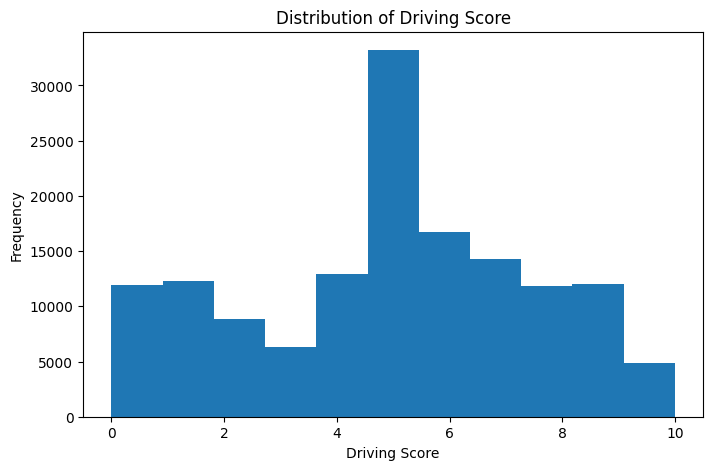

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Driving_Score"], bins=11)

plt.title("Distribution of Driving Score")
plt.xlabel("Driving Score")
plt.ylabel("Frequency")

plt.show()

# Driving Style Label Generation

The final driving behavior labels are derived from the overall Driving Score using quartile-based thresholds.

This approach maintains consistency with the feature scoring methodology by using the statistical distribution of the Driving Score rather than manually selected cutoff values.

The labels are assigned as follows:

- **Eco:** Driving Score ≤ 25th percentile (Q1)
- **Normal:** 25th percentile < Driving Score ≤ 75th percentile (Q3)
- **Aggressive:** Driving Score > 75th percentile (Q3)

Using quartile-based thresholds provides an objective and reproducible approach for generating driving behavior labels from unlabeled telemetry data.

In [48]:
def assign_driving_style(score):
    if score <= 3:
        return "Eco"
    elif score <= 7:
        return "Normal"
    else:
        return "Aggressive"

df["Driving_style"] = df["Driving_Score"].apply(assign_driving_style)

In [49]:
df["Driving_style"].value_counts()

Driving_style
Normal        77110
Eco           39335
Aggressive    28613
Name: count, dtype: int64

In [50]:
print(df["Driving_style"].value_counts(normalize=True) * 100)

Driving_style
Normal        53.158047
Eco           27.116740
Aggressive    19.725213
Name: proportion, dtype: float64


In [51]:
validation = (
    df.groupby("Driving_style")[
        [
            "Accel_pedal",
            "Speed",
            "Torque_Load",
            "Power_Magnitude",
            "MCU_Current_DC"
        ]
    ]
    .mean()
    .round(2)
)

validation

,Accel_pedal,Speed,Torque_Load,Power_Magnitude,MCU_Current_DC
Driving_style,,,,,
Aggressive,84.09,44.49,14464.56,53605.96,83.95
Eco,35.96,37.62,1303.13,15084.92,11.19
Normal,66.83,46.05,7633.27,30273.38,43.79


#### Observations

The engineered driving style labels exhibit meaningful differences across the selected telemetry features.

- Accelerator pedal position increases steadily from Eco to Aggressive driving, indicating higher driver demand.
- Torque Load shows a substantial increase, reflecting greater mechanical load during aggressive driving.
- Power Magnitude increases significantly, confirming higher electrical energy consumption.
- MCU DC Current also increases consistently, indicating increased motor current demand.
- Vehicle Speed remains relatively similar between Normal and Aggressive driving. This suggests that aggressive driving is characterized more by rapid acceleration, higher torque, and greater power demand than by sustained high speed.

Overall, the observed trends indicate that the rule-based target engineering methodology successfully captures realistic driving behavior patterns and provides a reliable target variable for the classification model.

## Step 2 — Create a Separate Model-1 Dataset

To prevent Model 1 preprocessing and feature selection from affecting the
full telemetry dataset required for Model 2, a separate dataframe is created.

Model 1 uses the engineered driving-behavior features and the derived
`Driving_style` target, while the original `df` is preserved for subsequent
model development.

In [87]:
# Create a separate dataframe for Model 1
df_model1 = df.copy()

print("Original dataframe shape:", df.shape)
print("Model 1 dataframe shape:", df_model1.shape)

Original dataframe shape: (145058, 47)
Model 1 dataframe shape: (145058, 47)


## Step 3 — Validate the Model-1 Dataset

Before selecting features or training the classification models, the Model-1
dataset is validated to ensure that:

- the dataset contains the expected number of observations,
- the `Driving_style` target variable is present,
- the target does not contain missing values,
- the three driving-style classes are correctly represented, and
- the class distribution is understood before model training.

All Model-1 preprocessing and modeling will be performed on `df_model1`.
The original `df` will remain unchanged for the subsequent Model-2 workflow.

In [88]:
# Check Model-1 dataset shape
print("Model 1 dataset shape:", df_model1.shape)

# Check target column
print("\nTarget column present:", "Driving_style" in df_model1.columns)

# Check missing values in target
print(
    "\nMissing Driving_style values:",
    df_model1["Driving_style"].isna().sum()
)

# Check class distribution
print("\nDriving Style Distribution:")
print(df_model1["Driving_style"].value_counts())

# Check class proportions
print("\nDriving Style Proportions:")
print(
    df_model1["Driving_style"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Model 1 dataset shape: (145058, 47)

Target column present: True

Missing Driving_style values: 0

Driving Style Distribution:
Driving_style
Normal        77110
Eco           39335
Aggressive    28613
Name: count, dtype: int64

Driving Style Proportions:
Driving_style
Normal        53.16
Eco           27.12
Aggressive    19.73
Name: proportion, dtype: float64


## Step 4 — Define Model-1 Feature Sets

Two feature sets are prepared for the driving-style classification problem.

### Model 1A — 15 Features

The 15-feature model represents a broader vehicle-state representation,
including vehicle dynamics, acceleration demand, torque, electrical
characteristics, thermal information, battery state, and engineered features.

This model is used as the broader baseline for driving-style classification.

### Model 1B — 8 Features

The 8-feature model is a reduced feature set containing the most relevant
and interpretable variables selected from the broader feature set.

The purpose of comparing the two feature sets is to determine whether a
smaller feature set can achieve comparable classification performance while
reducing model complexity and feature redundancy.

Both models use the same target variable:

`Driving_style`


In [90]:
# ---------------------------------------------
# Model 1A — 15 Feature Set
# ---------------------------------------------

features_15 = [
    "Speed",
    "Accel_pedal",
    "Torque",
    "MCU_torque",
    "MCU_Speed",
    "MCU_Current_DC",
    "MCU_Voltage_DC",
    "MCU_AC_Current",
    "MCU_AC_Voltage",
    "MCU_temp",
    "Motor_temp",
    "Total_SOC",
    "Torque_Load",
    "Power_Magnitude",
    "Temp_diff"
]

X_15 = df_model1[features_15]
y = df_model1["Driving_style"]

print("15-feature matrix shape:", X_15.shape)
print("Target shape:", y.shape)

15-feature matrix shape: (145058, 15)
Target shape: (145058,)


## Step 5 — Define Model-1 Reduced Feature Set

A reduced 8-feature set is created from the broader 15-feature set.

The purpose of the reduced model is to determine whether driving style
can be classified effectively using a smaller set of features while
reducing feature redundancy and model complexity.

The 8-feature model uses the most relevant vehicle-dynamics, driver-input,
mechanical, electrical, and thermal characteristics identified during
the feature-selection and correlation-analysis stages.

The same target variable, `Driving_style`, is used for both the 15-feature
and 8-feature models.


In [93]:
# ---------------------------------------------
# Model 1B — 8 Feature Set
# ---------------------------------------------

features_8 = [
    "Speed",
    "Accel_pedal",
    "Torque_Load",
    "MCU_Current_DC",
    "Power_Magnitude",
    "Temp_diff",
    "Total_SOC",
    "Torque_Ratio"
]

X_8 = df_model1[features_8]

print("8-feature matrix shape:", X_8.shape)
print("Target shape:", y.shape)

8-feature matrix shape: (145058, 8)
Target shape: (145058,)


## Step 6 — Train-Test Split

A common stratified train-test split is created for both feature sets.

Using the same row indices for both models ensures that the 15-feature
and 8-feature models are evaluated under identical conditions.

Stratification preserves the proportion of the three driving-style
classes — Normal, Eco, and Aggressive — in both the training and
testing datasets.

An 80:20 split is used, with a fixed random state to ensure
reproducibility.

In [96]:
# Common stratified train-test split


X15_train, X15_test, y_train, y_test = train_test_split(
    X_15,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Use the SAME row indices for the 8-feature dataset
X8_train = X_8.loc[X15_train.index]
X8_test = X_8.loc[X15_test.index]

print("15-feature training shape:", X15_train.shape)
print("15-feature testing shape :", X15_test.shape)

print("8-feature training shape :", X8_train.shape)
print("8-feature testing shape  :", X8_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape :", y_test.shape)

15-feature training shape: (116046, 15)
15-feature testing shape : (29012, 15)
8-feature training shape : (116046, 8)
8-feature testing shape  : (29012, 8)
Training target shape: (116046,)
Testing target shape : (29012,)


## Step 7 — Verify Class Distribution After Train-Test Split

Because the target variable contains three driving styles, stratification
was used during the train-test split.

This step verifies that the proportions of Normal, Eco, and Aggressive
driving styles remain approximately consistent between the original
dataset, training set, and testing set.

This check ensures that the model evaluation is not affected by an
unbalanced train-test split.

In [97]:
# ---------------------------------------------
# Verify class distribution
# ---------------------------------------------

print("Original Dataset:")
print(y.value_counts(normalize=True).mul(100).round(2))

print("\nTraining Dataset:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting Dataset:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Original Dataset:
Driving_style
Normal        53.16
Eco           27.12
Aggressive    19.73
Name: proportion, dtype: float64

Training Dataset:
Driving_style
Normal        53.16
Eco           27.12
Aggressive    19.72
Name: proportion, dtype: float64

Testing Dataset:
Driving_style
Normal        53.16
Eco           27.12
Aggressive    19.73
Name: proportion, dtype: float64


## Step 8 — Feature Scaling for Logistic Regression

Logistic Regression is sensitive to the scale of input features.

StandardScaler is used to standardize the numerical features so that
each feature has approximately zero mean and unit variance.

Two separate scalers are used:

- One scaler for the 15-feature model
- One scaler for the 8-feature model

The scalers are fitted only on the training data and then applied to
both training and testing data. This prevents information from the
testing set from leaking into the training process.

In [98]:
# Scale 15-feature dataset


scaler_15 = StandardScaler()

X15_train_scaled = scaler_15.fit_transform(X15_train)
X15_test_scaled = scaler_15.transform(X15_test)


# ---------------------------------------------
# Scale 8-feature dataset
# ---------------------------------------------

scaler_8 = StandardScaler()

X8_train_scaled = scaler_8.fit_transform(X8_train)
X8_test_scaled = scaler_8.transform(X8_test)


# ---------------------------------------------
# Verify shapes
# ---------------------------------------------

print("15-feature scaled training:", X15_train_scaled.shape)
print("15-feature scaled testing :", X15_test_scaled.shape)

print("8-feature scaled training :", X8_train_scaled.shape)
print("8-feature scaled testing  :", X8_test_scaled.shape)

15-feature scaled training: (116046, 15)
15-feature scaled testing : (29012, 15)
8-feature scaled training : (116046, 8)
8-feature scaled testing  : (29012, 8)


## Step 9 — Logistic Regression Using 15 Features

Logistic Regression is used as the first baseline classification model
for predicting driving style.

The model is trained using the 15 engineered features after standardization.

A baseline model is important because it provides a simple and
interpretable reference point against which the reduced 8-feature model
and the more complex Random Forest model can later be compared.

The model is evaluated on the held-out testing dataset, which was not
used during training.

In [99]:

# Train Logistic Regression - 15 Features

lr_15 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_15.fit(
    X15_train_scaled,
    y_train
)

print("15-feature Logistic Regression training completed.")

15-feature Logistic Regression training completed.


## Step 10 — Evaluate 15-Feature Logistic Regression

The trained Logistic Regression model is evaluated on the unseen test
dataset.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

The classification report is especially important because the three
driving-style classes are not perfectly balanced.

# Driving Style Classification

## Problem Statement

The objective of this model is to classify the driving behavior of an electric vehicle into one of three categories:

- Eco
- Normal
- Aggressive

Unlike traditional supervised learning datasets, the telemetry data did not contain predefined driving behavior labels. Therefore, a rule-based target engineering approach was developed using multiple telemetry features, including accelerator pedal position, vehicle speed, torque load, electrical power demand, and motor controller current.

The engineered driving style labels are used as the target variable for training a multi-class classification model capable of predicting driving behavior from real-time EV telemetry data.

15-Feature Logistic Regression Accuracy:
0.9455053081483524

Classification Report:

              precision    recall  f1-score   support

  Aggressive       0.92      0.90      0.91      5723
         Eco       0.97      0.96      0.96      7867
      Normal       0.94      0.95      0.95     15422

    accuracy                           0.95     29012
   macro avg       0.94      0.94      0.94     29012
weighted avg       0.95      0.95      0.95     29012


Confusion Matrix:

[[ 5145     0   578]
 [    0  7560   307]
 [  426   270 14726]]


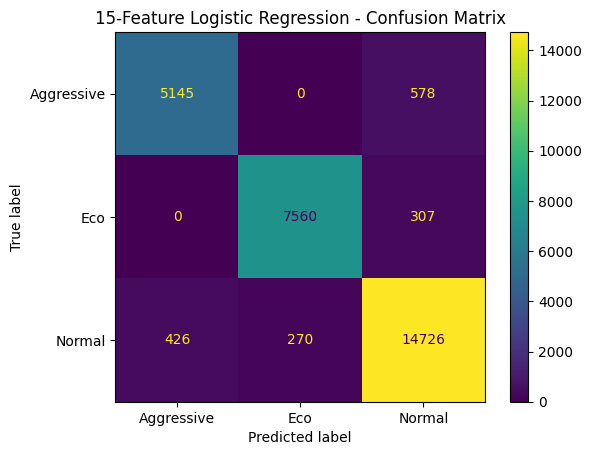

In [100]:
# Generate predictions


y_pred_lr15 = lr_15.predict(X15_test_scaled)


# ---------------------------------------------
# Accuracy
# ---------------------------------------------

accuracy_lr15 = accuracy_score(y_test, y_pred_lr15)

print("15-Feature Logistic Regression Accuracy:")
print(accuracy_lr15)


# ---------------------------------------------
# Classification Report
# ---------------------------------------------

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred_lr15
    )
)


# ---------------------------------------------
# Confusion Matrix
# ---------------------------------------------

cm_lr15 = confusion_matrix(
    y_test,
    y_pred_lr15
)

print("\nConfusion Matrix:\n")
print(cm_lr15)


# ---------------------------------------------
# Confusion Matrix Visualization
# ---------------------------------------------

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr15,
    display_labels=lr_15.classes_
).plot()

plt.title("15-Feature Logistic Regression - Confusion Matrix")
plt.show()

## Step 11 — Logistic Regression Using 8 Features

To evaluate whether the model can achieve comparable performance with a
smaller and more focused feature set, Logistic Regression is trained
using the selected 8 features.

This reduced-feature model is compared against the 15-feature baseline
using the same train-test split and evaluation metrics.

The objective is to determine whether the additional seven features
provide meaningful predictive value.

In [101]:
# Train Logistic Regression - 8 Features


lr_8 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_8.fit(
    X8_train_scaled,
    y_train
)

print("8-feature Logistic Regression training completed.")

8-feature Logistic Regression training completed.


## Step 12 — Evaluate 8-Feature Logistic Regression

The 8-feature Logistic Regression model is evaluated on the same
unseen test dataset used for the 15-feature model.

The results will be compared with the 15-feature baseline using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

This comparison helps determine whether the reduced feature set can
retain most of the predictive performance while making the model
simpler and more efficient.

8-Feature Logistic Regression Accuracy:
0.9403005652833311

Classification Report:

              precision    recall  f1-score   support

  Aggressive       0.92      0.89      0.91      5723
         Eco       0.96      0.95      0.96      7867
      Normal       0.94      0.95      0.94     15422

    accuracy                           0.94     29012
   macro avg       0.94      0.93      0.94     29012
weighted avg       0.94      0.94      0.94     29012


Confusion Matrix:

[[ 5120     0   603]
 [    1  7499   367]
 [  441   320 14661]]


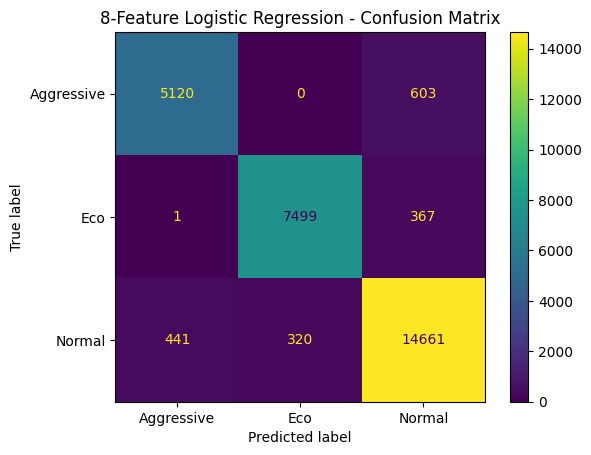

In [102]:
# Generate predictions


y_pred_lr8 = lr_8.predict(X8_test_scaled)


# ---------------------------------------------
# Accuracy
# ---------------------------------------------

accuracy_lr8 = accuracy_score(y_test, y_pred_lr8)

print("8-Feature Logistic Regression Accuracy:")
print(accuracy_lr8)


# ---------------------------------------------
# Classification Report
# ---------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr8
    )
)


# ---------------------------------------------
# Confusion Matrix
# ---------------------------------------------

cm_lr8 = confusion_matrix(
    y_test,
    y_pred_lr8
)

print("\nConfusion Matrix:\n")
print(cm_lr8)


# ---------------------------------------------
# Confusion Matrix Visualization
# ---------------------------------------------

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr8,
    display_labels=lr_8.classes_
).plot()

plt.title("8-Feature Logistic Regression - Confusion Matrix")
plt.show()

## Step 13 — Comparison of 15-Feature and 8-Feature Logistic Regression

The two Logistic Regression models are compared to understand the
effect of feature reduction.

Both models were trained using:

- The same target variable
- The same stratified train-test split
- The same Logistic Regression algorithm
- Standardized features
- The same evaluation dataset

This provides a fair comparison between the full and reduced feature
sets.

In [103]:
# Compare Logistic Regression Models


lr_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 15 Features",
        "Logistic Regression - 8 Features"
    ],
    "Features": [15, 8],
    "Accuracy": [
        accuracy_lr15,
        accuracy_lr8
    ]
})

lr_comparison["Accuracy (%)"] = (
    lr_comparison["Accuracy"] * 100
).round(2)

lr_comparison

,Model,Features,Accuracy,Accuracy (%)
0,Logistic Regression - 15 Features,15,0.945505,94.55
1,Logistic Regression - 8 Features,8,0.940301,94.03


## Step 14 — Random Forest Using 15 Features

Random Forest is introduced as a nonlinear classification model.

Unlike Logistic Regression, Random Forest can capture nonlinear
relationships and feature interactions between vehicle telemetry
variables.

The 15-feature dataset is used first so that Random Forest can be
compared directly with the 15-feature Logistic Regression baseline.

Both training and testing performance will be evaluated. Comparing
these two results is important for identifying potential overfitting.

A large difference between training and testing performance would
indicate that the model is fitting the training data too closely.

In [104]:
# Train Random Forest - 15 Features


rf_15 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_15.fit(
    X15_train,
    y_train
)

print("15-feature Random Forest training completed.")

15-feature Random Forest training completed.


## Step 15 — Evaluate 15-Feature Random Forest

The Random Forest model is evaluated on both the training and testing
datasets.

Comparing training and testing performance helps identify overfitting.

A model that performs extremely well on the training data but
substantially worse on unseen testing data may be overfitting.

The testing classification report and confusion matrix are also
examined to understand class-level performance.

15-Feature Random Forest
---------------------------------------------
Training Accuracy: 0.9998
Testing Accuracy : 0.9990
Accuracy Gap     : 0.0008

Testing Classification Report:

              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      5723
         Eco       1.00      1.00      1.00      7867
      Normal       1.00      1.00      1.00     15422

    accuracy                           1.00     29012
   macro avg       1.00      1.00      1.00     29012
weighted avg       1.00      1.00      1.00     29012


Testing Confusion Matrix:

[[ 5717     0     6]
 [    0  7867     0]
 [   11    12 15399]]


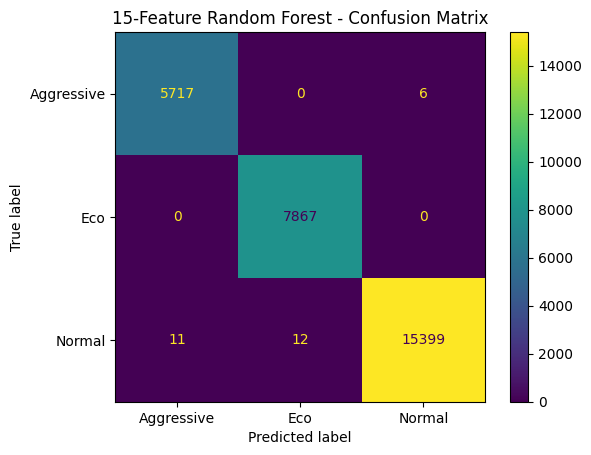

In [105]:
# Training predictions


y_train_pred_rf15 = rf_15.predict(X15_train)

train_accuracy_rf15 = accuracy_score(
    y_train,
    y_train_pred_rf15
)


# ---------------------------------------------
# Testing predictions
# ---------------------------------------------

y_test_pred_rf15 = rf_15.predict(X15_test)

test_accuracy_rf15 = accuracy_score(
    y_test,
    y_test_pred_rf15
)


# ---------------------------------------------
# Print training vs testing accuracy
# ---------------------------------------------

print("15-Feature Random Forest")
print("-" * 45)

print(f"Training Accuracy: {train_accuracy_rf15:.4f}")
print(f"Testing Accuracy : {test_accuracy_rf15:.4f}")

print(
    f"Accuracy Gap     : "
    f"{train_accuracy_rf15 - test_accuracy_rf15:.4f}"
)


# ---------------------------------------------
# Testing Classification Report
# ---------------------------------------------

print("\nTesting Classification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred_rf15
    )
)


# ---------------------------------------------
# Testing Confusion Matrix
# ---------------------------------------------

cm_rf15 = confusion_matrix(
    y_test,
    y_test_pred_rf15
)

print("\nTesting Confusion Matrix:\n")
print(cm_rf15)


# ---------------------------------------------
# Confusion Matrix Visualization
# ---------------------------------------------

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf15,
    display_labels=rf_15.classes_
).plot()

plt.title("15-Feature Random Forest - Confusion Matrix")
plt.show()

## Step 16 — Random Forest Feature Importance

Feature importance is examined to understand which telemetry variables
contribute most strongly to the Random Forest's driving-style
predictions.

This analysis also provides a diagnostic check because unusually high
importance from a feature that was directly involved in constructing
the target variable may indicate potential target leakage.

The feature importance results will therefore be interpreted together
with the target-generation methodology.

In [106]:
# Random Forest Feature Importance


feature_importance_rf15 = pd.DataFrame({
    "Feature": X15_train.columns,
    "Importance": rf_15.feature_importances_
})

feature_importance_rf15 = (
    feature_importance_rf15
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print(feature_importance_rf15)

            Feature  Importance
0       Torque_Load    0.226675
1       Accel_pedal    0.171493
2    MCU_Current_DC    0.157180
3   Power_Magnitude    0.141782
4            Torque    0.077785
5        MCU_torque    0.063661
6    MCU_AC_Voltage    0.057645
7    MCU_AC_Current    0.039999
8             Speed    0.026334
9         MCU_Speed    0.024536
10   MCU_Voltage_DC    0.004930
11         MCU_temp    0.003253
12        Total_SOC    0.002053
13       Motor_temp    0.001549
14        Temp_diff    0.001125


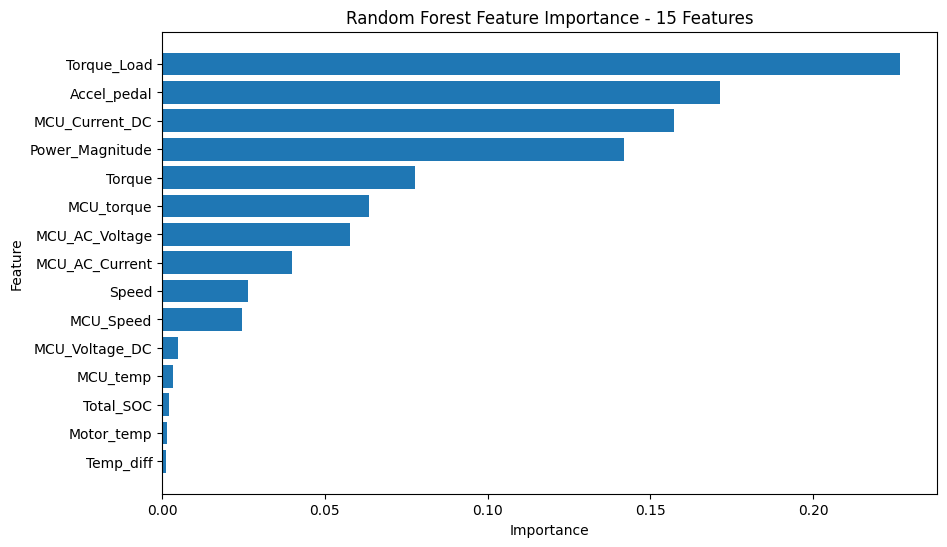

In [108]:
# Plot Feature Importance


plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_rf15["Feature"],
    feature_importance_rf15["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - 15 Features")

plt.show()

## Step 17 — Random Forest Using 8 Features

The Random Forest model is now trained using the reduced 8-feature
dataset.

The same Random Forest configuration used for the 15-feature model is
retained so that the comparison between the two feature sets is fair.

The objective is to determine whether the reduced feature set can
maintain the strong nonlinear classification performance while using
fewer telemetry variables.

In [109]:

# Train Random Forest - 8 Features


rf_8 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_8.fit(
    X8_train,
    y_train
)

print("8-feature Random Forest training completed.")

8-feature Random Forest training completed.


## Step 18 — Evaluate 8-Feature Random Forest

The 8-feature Random Forest is evaluated on both the training and
testing datasets.

Training and testing accuracy are compared to identify potential
overfitting and assess how well the reduced feature set generalizes
to unseen data.

The testing classification report and confusion matrix are also
examined to evaluate performance for each driving-style class.

8-Feature Random Forest
---------------------------------------------
Training Accuracy: 0.9998
Testing Accuracy : 0.9992
Accuracy Gap     : 0.0006

Testing Classification Report:

              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      5723
         Eco       1.00      1.00      1.00      7867
      Normal       1.00      1.00      1.00     15422

    accuracy                           1.00     29012
   macro avg       1.00      1.00      1.00     29012
weighted avg       1.00      1.00      1.00     29012


Testing Confusion Matrix:

[[ 5717     0     6]
 [    0  7867     0]
 [    5    11 15406]]


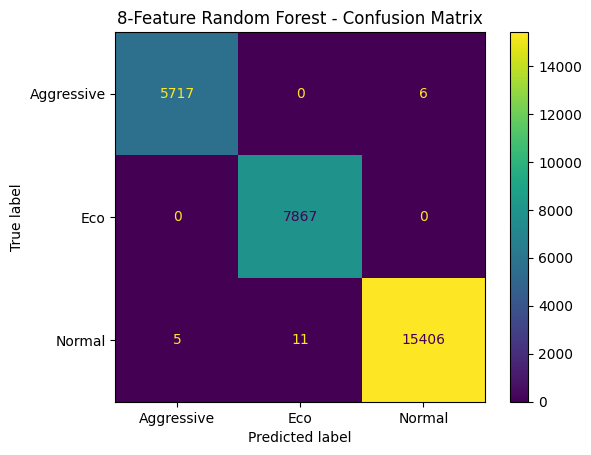

In [110]:
# Training predictions

y_train_pred_rf8 = rf_8.predict(X8_train)

train_accuracy_rf8 = accuracy_score(
    y_train,
    y_train_pred_rf8
)


# ---------------------------------------------
# Testing predictions
# ---------------------------------------------

y_test_pred_rf8 = rf_8.predict(X8_test)

test_accuracy_rf8 = accuracy_score(
    y_test,
    y_test_pred_rf8
)


# ---------------------------------------------
# Training vs Testing Accuracy
# ---------------------------------------------

print("8-Feature Random Forest")
print("-" * 45)

print(f"Training Accuracy: {train_accuracy_rf8:.4f}")
print(f"Testing Accuracy : {test_accuracy_rf8:.4f}")

print(
    f"Accuracy Gap     : "
    f"{train_accuracy_rf8 - test_accuracy_rf8:.4f}"
)


# ---------------------------------------------
# Testing Classification Report
# ---------------------------------------------

print("\nTesting Classification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred_rf8
    )
)


# ---------------------------------------------
# Testing Confusion Matrix
# ---------------------------------------------

cm_rf8 = confusion_matrix(
    y_test,
    y_test_pred_rf8
)

print("\nTesting Confusion Matrix:\n")
print(cm_rf8)


# ---------------------------------------------
# Confusion Matrix Visualization
# ---------------------------------------------

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf8,
    display_labels=rf_8.classes_
).plot()

plt.title("8-Feature Random Forest - Confusion Matrix")
plt.show()

## Step 19 — Model Performance Comparison

Four classification experiments are compared to determine the most
appropriate model and feature set for predicting driving style.

The comparison considers testing accuracy and the training-testing
accuracy gap.

The objective is not simply to select the model with the highest
accuracy, but to balance predictive performance, generalization,
feature efficiency, and interpretability.

In [111]:
# Final Model Comparison


model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 15 Features",
        "Logistic Regression - 8 Features",
        "Random Forest - 15 Features",
        "Random Forest - 8 Features"
    ],

    "Features": [
        15,
        8,
        15,
        8
    ],

    "Testing Accuracy": [
        0.9455053081483524,
        0.9403005652833311,
        test_accuracy_rf15,
        test_accuracy_rf8
    ],

    "Training Accuracy": [
        np.nan,
        np.nan,
        train_accuracy_rf15,
        train_accuracy_rf8
    ]
})

# Calculate accuracy gap for Random Forest models
model_comparison["Accuracy Gap"] = (
    model_comparison["Training Accuracy"]
    - model_comparison["Testing Accuracy"]
)

model_comparison

,Model,Features,Testing Accuracy,Training Accuracy,Accuracy Gap
0,Logistic Regression - 15 Features,15,0.945505,NaN,NaN
1,Logistic Regression - 8 Features,8,0.940301,NaN,NaN
2,Random Forest - 15 Features,15,0.999000,0.999785,0.000784
3,Random Forest - 8 Features,8,0.999242,0.999802,0.000560


In [112]:
print(model_comparison.to_string(index=False))

                            Model  Features  Testing Accuracy  Training Accuracy  Accuracy Gap
Logistic Regression - 15 Features        15          0.945505                NaN           NaN
 Logistic Regression - 8 Features         8          0.940301                NaN           NaN
      Random Forest - 15 Features        15          0.999000           0.999785      0.000784
       Random Forest - 8 Features         8          0.999242           0.999802      0.000560


## Step 20 — Final Feature Set for Model 1

Based on the comparison of Logistic Regression and Random Forest
models, the 8-feature Random Forest achieved the highest testing
accuracy while using fewer input variables.

The selected 8-feature set is retained as the final candidate feature
set for Model 1.

Reducing the feature set helps simplify the model, reduce the number
of telemetry signals required during inference, and improve practical
deployment feasibility.

In [114]:
print("Final Model 1 Features:")
print("-" * 40)

for i, feature in enumerate(features_8, start=1):
    print(f"{i}. {feature}")

print("\nNumber of features:", len(features_8))

Final Model 1 Features:
----------------------------------------
1. Speed
2. Accel_pedal
3. Torque_Load
4. MCU_Current_DC
5. Power_Magnitude
6. Temp_diff
7. Total_SOC
8. Torque_Ratio

Number of features: 8


## Step 21 — Validate Feature–Target Relationships

The final 8 features are examined against the engineered driving-style
target to identify potential target leakage or features that may be
directly responsible for constructing the target.

This validation is important because the Random Forest achieved
near-perfect testing accuracy.

A high-performing model is acceptable only when the input features
represent information that would genuinely be available when making
a prediction in a real vehicle telemetry scenario.

In [115]:
# Feature vs Target Analysis


print("Final 8 Features:")
print(features_8)

print("\nTarget Distribution:")
print(df["Driving_style"].value_counts())

print("\nMean Feature Values by Driving Style:")
print(
    df.groupby("Driving_style")[features_8]
      .mean()
      .round(3)
)

Final 8 Features:
['Speed', 'Accel_pedal', 'Torque_Load', 'MCU_Current_DC', 'Power_Magnitude', 'Temp_diff', 'Total_SOC', 'Torque_Ratio']

Target Distribution:
Driving_style
Normal        77110
Eco           39335
Aggressive    28613
Name: count, dtype: int64

Mean Feature Values by Driving Style:
                Speed  Accel_pedal  Torque_Load  MCU_Current_DC  \
Driving_style                                                     
Aggressive     44.487       84.092    14464.559          83.955   
Eco            37.616       35.958     1303.134          11.194   
Normal         46.048       66.826     7633.268          43.789   

               Power_Magnitude  Temp_diff  Total_SOC  Torque_Ratio  
Driving_style                                                       
Aggressive           53605.955      5.011    146.704         9.113  
Eco                  15084.916      4.513    132.319         4.865  
Normal               30273.377      4.690    134.620         4.379  


## Model 1 — Target Construction and Validation

### Driving Style Target Construction

Driving style was not directly available as a labeled target in the
original telemetry data. Therefore, a domain-informed scoring approach
was used to derive the target variable.

Five behavioral telemetry signals were converted into individual
behavior scores:

- Accel_pedal
- Speed
- Torque_Load
- Power_Magnitude
- MCU_Current_DC

These individual scores were combined to create a `Driving_Score`.

The final driving-style classes were then assigned using the following
thresholds:

- Driving_Score <= 3 → Eco
- Driving_Score 4–7 → Normal
- Driving_Score > 7 → Aggressive

Therefore, the target-generation pipeline was:

Raw Telemetry
    ↓
Behavioral Feature Scores
    ↓
Driving_Score
    ↓
Driving_style
    ↓
Machine Learning Classification

### Final Model

Four classification experiments were evaluated:

1. Logistic Regression — 15 features
2. Logistic Regression — 8 features
3. Random Forest — 15 features
4. Random Forest — 8 features

The 8-feature Random Forest achieved the best testing performance:

- Training Accuracy: 99.98%
- Testing Accuracy: 99.92%
- Accuracy Gap: 0.06 percentage points

The final 8 features were:

- Speed
- Accel_pedal
- Torque_Load
- MCU_Current_DC
- Power_Magnitude
- Temp_diff
- Total_SOC
- Torque_Ratio

### Interpretation and Limitation

The high Random Forest performance is expected to some extent because
five of the selected telemetry features were also used in constructing
the engineered Driving_Score.

Therefore, the model should be interpreted as learning and reproducing
the engineered driving-style classification framework rather than
predicting an independently labeled real-world driving-style target.

The small training-testing accuracy gap indicates that the model does
not show conventional train-test overfitting. However, the engineered
nature of the target should be considered when interpreting the very
high accuracy.

This limitation is explicitly documented to ensure transparent
interpretation of the model results.

# Model 2: Vehicle Energy Efficiency Prediction (Regression)

## Problem Statement

Efficient utilization of battery energy is one of the most important performance indicators of an electric vehicle. Rather than predicting cumulative battery discharge, this model aims to estimate the **vehicle's energy efficiency**, defined as the amount of electrical energy consumed per unit distance travelled.

Vehicle energy efficiency is influenced by several real-time operating conditions, including vehicle speed, acceleration, battery current, battery voltage, motor torque, state of charge (SOC), and thermal characteristics. Predicting this metric enables intelligent energy management and provides valuable insights into vehicle performance.

The developed regression model can support various real-world applications such as:

- Battery energy optimization
- Driving range estimation
- Eco-driving recommendations
- Fleet energy monitoring
- Driver behavior analysis
- Intelligent Battery Management Systems (BMS)

Unlike the previous classification model, which categorizes driving behavior into **Eco**, **Normal**, and **Aggressive**, this regression model predicts a continuous numerical value representing the vehicle's energy efficiency under different driving conditions.

## Step 1: Calculate Incremental Energy Consumption

The battery discharge energy provided in the original dataset represents cumulative energy counters. To obtain the actual energy consumed between consecutive telemetry observations, the difference between successive readings is calculated.

Negative differences occur due to counter resets or the beginning of new driving sessions. Since negative energy consumption is not physically meaningful, such values are replaced with zero.

### Battery Discharge Energy Signal Validation

The dataset contains two battery discharge-energy signals:

- `B_Batt_Discharge_energy`
- `A_Batt_Discharge energy`

Before calculating incremental energy consumption, both signals were compared to determine whether they represent independent energy quantities or highly correlated measurements.

The two signals show very similar behavior, with a correlation of approximately **0.9997**. Therefore, adding both signals together could potentially introduce redundancy or double-count the same underlying energy behavior.

For the energy-consumption calculation, `B_Batt_Discharge_energy` is selected as the representative cumulative discharge-energy signal.

The A-channel signal is retained for validation and comparison but is not summed with the B-channel signal.

In [119]:
energy_cols = [
    "B_Batt_Discharge_energy",
    "A_Batt_Discharge energy"
]

print(df[energy_cols].describe())

print("\nCorrelation:")
print(df[energy_cols].corr())

print("\nFirst 10 rows:")
print(df[[
    "Time",
    "Driving_Segment_ID",
    "B_Batt_Discharge_energy",
    "A_Batt_Discharge energy"
]].head(10))

       B_Batt_Discharge_energy  A_Batt_Discharge energy
count            145058.000000            145058.000000
mean               6375.416498              6256.562114
std                  19.656903                19.030491
min                6341.400000              6223.100000
25%                6357.700000              6239.400000
50%                6375.700000              6257.700000
75%                6392.800000              6273.300000
max                6407.100000              6286.400000

Correlation:
                         B_Batt_Discharge_energy  A_Batt_Discharge energy
B_Batt_Discharge_energy                 1.000000                 0.999696
A_Batt_Discharge energy                 0.999696                 1.000000

First 10 rows:
    Time Driving_Segment_ID  B_Batt_Discharge_energy  A_Batt_Discharge energy
0  137.1                0_0                   6341.4                   6223.1
1  137.2                0_0                   6341.4                   6223.1
2  137.3  

In [120]:
print(
    df[[
        "B_Batt_Discharge_energy",
        "A_Batt_Discharge energy"
    ]].tail(10)
)

        B_Batt_Discharge_energy  A_Batt_Discharge energy
145048                   6371.9                   6253.7
145049                   6371.9                   6253.7
145050                   6371.9                   6253.7
145051                   6371.9                   6253.7
145052                   6371.9                   6253.7
145053                   6371.9                   6253.7
145054                   6371.9                   6253.7
145055                   6405.7                   6285.2
145056                   6405.7                   6285.2
145057                   6405.7                   6285.2


### Incremental Energy Consumption

`B_Batt_Discharge_energy` represents cumulative battery discharge energy. To estimate the energy consumed between consecutive telemetry observations, the difference between consecutive cumulative values is calculated.

The calculation is performed separately within each `Driving_Segment_ID` so that energy values from different continuous driving segments are not compared.

Negative differences are clipped to zero to prevent resets or decreases in the cumulative signal from being interpreted as negative energy consumption.

In [121]:
# Calculate incremental discharge energy within each continuous driving segment

df["Energy_Consumed"] = (
    df.groupby("Driving_Segment_ID")["B_Batt_Discharge_energy"]
      .diff()
      .clip(lower=0)
      .fillna(0)
)

In [122]:
print(df["Energy_Consumed"].describe())

print("\nNegative values:")
print((df["Energy_Consumed"] < 0).sum())

count    145058.000000
mean          0.000472
std           0.006856
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.100000
Name: Energy_Consumed, dtype: float64

Negative values:
0


In [123]:
print("Total observations:", len(df))

print(
    "Non-zero Energy_Consumed:",
    (df["Energy_Consumed"] > 0).sum()
)

print(
    "Percentage non-zero:",
    round(
        (df["Energy_Consumed"] > 0).mean() * 100,
        2
    ),
    "%"
)

print("\nNon-zero Energy_Consumed values:")
print(
    df.loc[
        df["Energy_Consumed"] > 0,
        "Energy_Consumed"
    ].value_counts().head(20)
)

Total observations: 145058
Non-zero Energy_Consumed: 685
Percentage non-zero: 0.47 %

Non-zero Energy_Consumed values:
Energy_Consumed
0.1    410
0.1    275
Name: count, dtype: int64


In [124]:
print(
    df.groupby("Driving_Segment_ID")["Energy_Consumed"]
      .sum()
      .describe()
)

count    3389.000000
mean        0.020212
std         0.047690
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.400000
Name: Energy_Consumed, dtype: float64


## Step 2: Calculate Distance Travelled

Vehicle energy efficiency is defined as electrical energy consumed per unit distance travelled. Therefore, distance travelled must be calculated before constructing the regression target.

The telemetry data is sampled at approximately 0.1-second intervals. However, occasional gaps exist between observations. To prevent distance calculations from incorrectly spanning unrelated portions of the dataset, the previously created Driving_Segment_ID is used to calculate the time difference within each continuous driving segment.

Distance travelled for each observation is calculated from vehicle speed and the time interval between consecutive observations.

The resulting distance is expressed in kilometres.

In [145]:
df["dt"] = (
    df.groupby("Driving_Segment_ID")["Time"]
      .diff()
)

In [146]:
df["Distance_Travelled"] = (
    df["Speed"] * df["dt"] / 3600
)

In [147]:
print("Distance statistics:")
print(df["Distance_Travelled"].describe())

print("\nMissing distance:",
      df["Distance_Travelled"].isna().sum())

print("Zero distance:",
      (df["Distance_Travelled"] == 0).sum())

print("Negative distance:",
      (df["Distance_Travelled"] < 0).sum())

Distance statistics:
count    141669.000000
mean          0.001368
std           0.001940
min           0.000028
25%           0.001222
50%           0.001306
75%           0.001361
max           0.069333
Name: Distance_Travelled, dtype: float64

Missing distance: 3389
Zero distance: 0
Negative distance: 0


In [148]:
df[[
    "Driving_Segment_ID",
    "Time",
    "Speed",
    "dt",
    "Distance_Travelled"
]].head(20)

,Driving_Segment_ID,Time,Speed,dt,Distance_Travelled
0,0_0,137.1,1,NaN,NaN
1,0_0,137.2,1,0.1,0.000028
2,0_0,137.3,1,0.1,0.000028
3,0_0,137.4,1,0.1,0.000028
4,0_0,137.5,1,0.1,0.000028
5,0_0,137.6,1,0.1,0.000028
6,0_1,167.8,1,NaN,NaN
7,0_1,167.9,1,0.1,0.000028
8,0_1,168.0,1,0.1,0.000028
9,0_2,472.2,1,NaN,NaN


## Step 3: Engineer Rolling Vehicle Energy Efficiency

The incremental energy consumption calculated from the cumulative battery discharge counter is sparse because the discharge-energy counter is updated at a lower frequency than the telemetry sampling rate.

Calculating energy efficiency from a single telemetry observation would therefore produce an unstable and highly sparse target.

To obtain a more meaningful measure of vehicle efficiency, a rolling window is used. The cumulative energy consumed and distance travelled over consecutive observations are calculated within each continuous driving segment.

Using the Driving Segment ID ensures that rolling calculations do not cross the boundaries between separate driving sessions.

Vehicle energy efficiency is defined as:

Vehicle Efficiency = Rolling Energy Consumed / Rolling Distance Travelled

This engineered continuous variable is used as the target for the regression model.

#### Step 1 — Round Energy

In [149]:
df["Energy_Consumed"] = df["Energy_Consumed"].round(3)

#### Step 2 — Choose rolling Window Size

In [150]:
window_size = 20      # approximately 2 seconds

#### Step 3 — Calculate rolling energy within each driving segment

In [152]:
df["Rolling_Energy"] = (
    df.groupby("Driving_Segment_ID")["Energy_Consumed"]
      .rolling(window=window_size, min_periods=window_size)
      .sum()
      .reset_index(level=0, drop=True)
)

#### Step 4 — Calculate rolling distance within each driving segment

In [154]:
df["Rolling_Distance"] = (
    df.groupby("Driving_Segment_ID")["Distance_Travelled"]
      .rolling(window=window_size, min_periods=window_size)
      .sum()
      .reset_index(level=0, drop=True)
)

#### Step 5 — Calculate Vehicle Efficiency

In [155]:
df["Vehicle_Efficiency"] = (
    df["Rolling_Energy"] / df["Rolling_Distance"]
)

In [156]:
print("Total rows:", len(df))

print("\nMissing values:")
print(df[[
    "Energy_Consumed",
    "Distance_Travelled",
    "Rolling_Energy",
    "Rolling_Distance",
    "Vehicle_Efficiency"
]].isna().sum())

print("\nInfinite efficiency values:")
print(
    np.isinf(df["Vehicle_Efficiency"]).sum()
)

print("\nZero rolling distance:")
print(
    (df["Rolling_Distance"] == 0).sum()
)


Total rows: 145058

Missing values:
Energy_Consumed           0
Distance_Travelled     3389
Rolling_Energy        42758
Rolling_Distance      44270
Vehicle_Efficiency    44270
dtype: int64

Infinite efficiency values:
0

Zero rolling distance:
0


#### Step 6— Inspect the Engineered Efficiency Target

The engineered vehicle efficiency target is examined to understand its distribution and identify potentially invalid or extreme values before model training.

In [157]:
print(df["Vehicle_Efficiency"].describe())

count    100788.000000
mean          0.340797
std           1.361450
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          75.000000
Name: Vehicle_Efficiency, dtype: float64


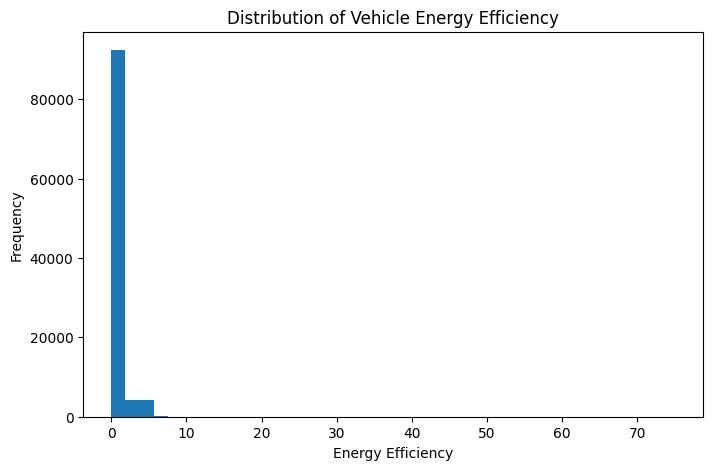

In [158]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Vehicle_Efficiency"].dropna(),
    bins=40
)

plt.title("Distribution of Vehicle Energy Efficiency")
plt.xlabel("Energy Efficiency")
plt.ylabel("Frequency")

plt.show()

In [159]:
print(
    "Valid Vehicle Efficiency values:",
    df["Vehicle_Efficiency"].notna().sum()
)

print(
    "Missing Vehicle Efficiency values:",
    df["Vehicle_Efficiency"].isna().sum()
)

Valid Vehicle Efficiency values: 100788
Missing Vehicle Efficiency values: 44270


In [161]:
print(
    "Negative efficiency values:",
    (df["Vehicle_Efficiency"] < 0).sum()
)

Negative efficiency values: 0


In [162]:
print("Total rows:", len(df))

print(
    "Non-zero Energy_Consumed:",
    (df["Energy_Consumed"] > 0).sum()
)

print(
    "Zero Energy_Consumed:",
    (df["Energy_Consumed"] == 0).sum()
)

print(
    "Percentage non-zero:",
    (df["Energy_Consumed"] > 0).mean() * 100
)

Total rows: 145058
Non-zero Energy_Consumed: 685
Zero Energy_Consumed: 144373
Percentage non-zero: 0.4722249031421914


In [163]:
print(df["Energy_Consumed"].describe())

count    145058.000000
mean          0.000472
std           0.006856
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.100000
Name: Energy_Consumed, dtype: float64


In [164]:
print(
    df.loc[
        df["Energy_Consumed"] > 0,
        ["Driving_Segment_ID", "Time", "Energy_Consumed"]
    ].head(20)
)

     Driving_Segment_ID     Time  Energy_Consumed
1237               1_42  13546.6              0.1
1551               2_22   9572.2              0.1
1911               2_36  13547.1              0.1
2349               3_30  13547.4              0.1
2746               4_28  13547.7              0.1
3530               6_25  10902.7              0.1
3998               7_22   9213.5              0.1
4954              10_15   8666.8              0.1
5284              11_17   8667.5              0.1
5602              12_16   8668.0              0.1
6026              13_25   8799.7              0.1
6142              13_41  11113.6              0.1
6397              14_27   8746.7              0.1
6873               15_0    538.3              0.1
7225              15_33   8949.7              0.1
7752              16_35   8949.3              0.1
7897               17_7   3343.8              0.1
8131              17_36   8946.6              0.1
8314               18_3    604.3              0.1


In [165]:
for window in [20, 50, 100, 200]:
    
    rolling_energy = (
        df.groupby("Driving_Segment_ID")["Energy_Consumed"]
          .rolling(window=window, min_periods=window)
          .sum()
          .reset_index(level=0, drop=True)
    )
    
    positive_pct = (
        (rolling_energy > 0).sum()
        / rolling_energy.notna().sum()
        * 100
    )
    
    print(
        f"Window {window:>3}: "
        f"{positive_pct:.2f}% positive rolling-energy windows"
    )

Window  20: 9.31% positive rolling-energy windows
Window  50: 22.92% positive rolling-energy windows
Window 100: 44.65% positive rolling-energy windows
Window 200: 80.74% positive rolling-energy windows


#### Step 7 — Verify the New Target

In [ ]:
print(df["Vehicle_Efficiency"].describe())

In [ ]:
plt.hist(df["Vehicle_Efficiency"], bins=40)

plt.title("Distribution of Vehicle Energy Efficiency")

plt.xlabel("Vehicle Efficiency")

plt.ylabel("Frequency")

plt.show()

In [ ]:
print(
    "Zero Efficiency (%):",
    (df["Vehicle_Efficiency"] == 0).mean()*100
)

In [ ]:
df[[
    "Rolling_Energy",
    "Rolling_Distance",
    "Vehicle_Efficiency"
]].head(15)

In [ ]:
df["Time"].diff().describe()

In [ ]:
print("Original rows:", len(df))
print("Rows after feature engineering:", len(df))

In [ ]:
X=df[features]

In [ ]:
y=df["Total_Discharge_energy"]

In [ ]:
# Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

### Model building using Random Forest algorithm

In [ ]:
reg_model = RandomForestRegressor(n_estimators=100)


In [ ]:
reg_model.fit(X_train, y_train)

In [ ]:
# model Evaluation

In [ ]:
y_test_pred=reg_model.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))